# Variables aleatorias

## Discretas:

Toman valores en un conjunto discreto (subconjunto de $\mathbb{N}$, $\mathbb{Z}$) puede ser finito o no. Por ejemplo el número de clientes que entran a una tienda o el número de veces que aparecen productos con defecto en un lote.

## Continuas:

Toman valores sobre un intervalo de $\mathbb{R}$. Por ejemplo, la temperatura de una sustancia o tiempo de vida de una bacteria.

## Mixtas:

Combinación de discretas y continuas. Por ejemplo el tiempo de espera en un banco el cual puede ser 0 si se atiende al momento o tomar un valor dentro de $\mathbb{R}$.

# DISCRETAS

## Variable aleatoria uniforme discreta

Una variable aleatoria $X$ tiene distribución uniforme discreta en el conjunto $\{x_{1},\dots,x_{n}\}$ si su función de masa de probabilidades está dada por

$$
f_{X}(k)=\mathbb{P}(X=k)=\begin{cases}
\frac{1}{n} &\quad \text{si } k\in\{x_{1},\dots,x_{n}\} \\
0 &\quad \text{en otro caso}
\end{cases}
$$

**Notación:** $X\sim Unif(x_{1},\dots,x_{n}).$

Se llama uniforme porque cada uno de los posibles valores de $X$ tienen la misma probabilidad.

Si $X\sim Unif(x_{1},\dots,x_{n})$, en este caso, se tiene:
$$\mathbb{E}[X] = \sum_{k}kf_{X}(k)=\frac{x_n + x_1}{2}.$$
y
$$\text{Var}(X) = \mathbb{E}[(X-\mathbb{E}[X])^{2}] =\sum_{k}(k-\mathbb{E}[X])^{2}f_{X}(k)=\frac{(x_n - x_1+1)^2-1}{12}$$

$\color{red}{\text{Ejercicio 1.}}$ Verifica que, en efecto, la esperanza y varianza de una variable uniforme está dada como antes.

**Ejemplo** Se lleva a cabo una rifa donde los boletos están enumerados del $00$ al $99$. Si $Y$ es la variable aleatoria definida como el número del boleto ganador, entonces:

$$
\mathbb{P}(Y=k)=\begin{cases}
	\frac{1}{100} &\quad \text{si } k=00,01,\dots,99 \\
	0 &\quad \text{en otro caso}
\end{cases}
$$

Consideremos que el premio de la rifa se determina a partir del número premiado de la siguiente forma: $X=Y+1$, donde $X$ es el monto del premio en pesos y $Y$ es el número premiado, entonces $X$ es una variable aleatoria, pues es una función de $Y$, y además se tiene

$$
f_{X}(k)=\begin{cases}
		\frac{1}{100} &\quad \text{si } x=1,2,\dots,100 \\
		0 &\quad \text{en otro caso}
	\end{cases}
$$

Entonces, la esperanza y varianza de $X$ están dados por:
$$\mathbb{E}[X] = \sum_{k=1}^{100}k\left(\frac{1}{100}\right) = \frac{1}{100}\sum_{k=1}^{100}k = \frac{1}{100}\left[\frac{100(100+1)}{2}\right] = 50.5$$
y
$$\text{Var}(X) = \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \sum_{k=1}^{100}k^{2}\left(\frac{1}{100}\right)-(50.5)^{2} = 833.25$$

Supongamos que nos interesa calcular la probabilidad de que el premio sea mayor a $\$80$, entonces
$$\mathbb{P}(X>80) = \sum_{k=81}^{100}\frac{1}{100} = \frac{20}{100} = 0.2$$
Su función de distribución esta dada por:

$$
F_{X}(x)=\mathbb{P}(X\le x)=\begin{cases}
		0 &\quad \text{si } x<1 \\
		\frac{x}{100} &\quad \text{si } x=1,2,\dots,100\\ 1 &\quad \text{si } x>100
	\end{cases}
$$


In [62]:
import numpy as np
import numpy.random as npr # Para generar números aleatorios

import matplotlib.pyplot as plt # Para crear gráficas



In [63]:
from scipy.stats import bernoulli, binom, poisson, geom, hypergeom, nbinom
from scipy.stats import expon, norm, gamma, beta


import random

import plotly.express as px
import plotly.graph_objects as go

import pandas as pd
import seaborn as sns

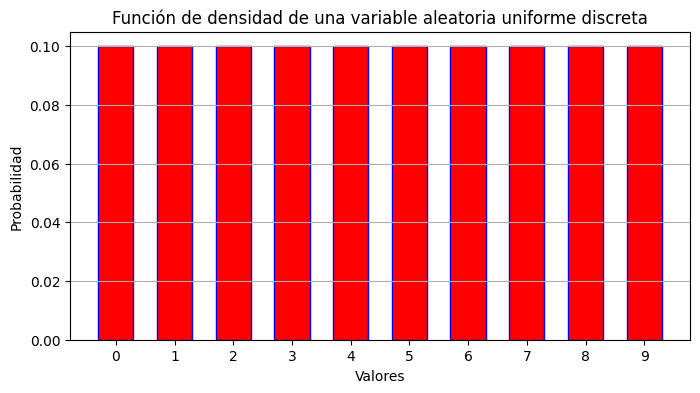

In [47]:
# Distribución uniforme discreta

min = 0
max = 10

x = np.arange(0,10)
x

# Vamos a crear la función de densidad (pmf (probability mass function))

pmf = np.full_like(x,1/(max-min),dtype=float) # crear un arreglo del mismo tamaño

plt.figure(figsize=(8,4))
plt.bar(x,pmf,width=0.6,color='red',edgecolor='b')
plt.xlabel("Valores")
plt.ylabel("Probabilidad")
plt.title("Función de densidad de una variable aleatoria uniforme discreta")
plt.xticks(np.arange(0,10))
plt.grid(axis='y')
plt.show()

## Variable aleatoria Bernoulli con parámetro $p\in (0,1)$.

El modelo probabilístico Bernoulli se aplica a un experimento cuyo espacio muestral está constituido sólo por dos resultados posibles, éxito y fracaso:

Se considerará una v.a $X$ sobre el espacio muestral $$\Omega=\{\text{éxito, fracaso}\}$$
de tal forma que

- $X(\{\text{éxito}\}) = 1$
- $X(\{\text{fracaso}\}) = 0$

Las probabilidades asociadas a este modelo son:

- $\mathbb{P}(\{\text{éxito}\}) = p$
- $\mathbb{P}(\{\text{fracaso}\}) = 1-p$

donde $0<p<1$.

Entonces la función de densidad de masa de probabilidades de $X$ está dada por:

$$
f_{X}(k)=\begin{cases}
p &\quad \text{si } k=1 \\
1-p &\quad \text{si } k=0
\end{cases}
$$

**Notación:** $X\sim \text{Ber}(p)$.

Esta variable aleatoria es muy importante. En la practica es usada para modelar situaciones en las cuales hay dos posibles resultados como:

- el estado de un teléfono en un momento dado: libre u ocupado.
- una persona pueda estar enferma o sana de una determinada enfermedad.
- la preferencia de una persona, la cual puede estar a favor o en contra de un candidato determinado.

Mediante la combinación de variables aleatorias Bernoulli es posible construir otras variables aleatorias.

### Esperanza y Varianza

Si $X\sim \text{Ber}(p)$, entonces su esperanza es:
\begin{align*}
\mathbb{E}[X] = \sum*{k=0}^{1}kf*{X}(k) = 1\cdot p + 0\cdot (1-p) = p.
\end{align*}

Y su varianza se calcula usando,
$$\mathbb{E}[X^{2}] = \sum_{k=0}^{1}k^{2}f_{X}(k) = 1^{2}\cdot p + 0^{2}\cdot (1-p) = p.$$
Por lo tanto,
$$\text{Var}(X)=\mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = p-p^{2} = p(1-p)$$


La función de densidad es: [0.7 0.3]


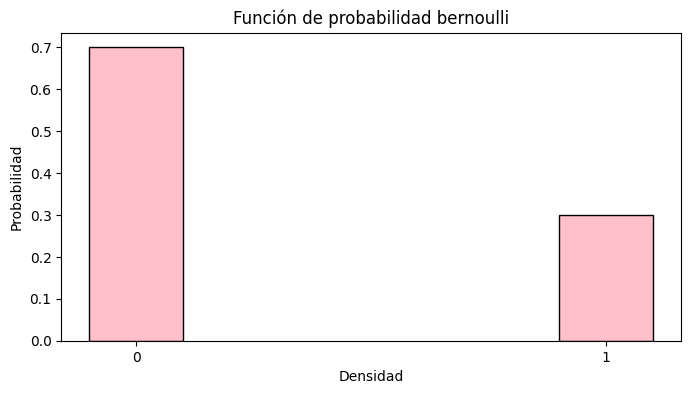

In [48]:
# Grafica de la distribución Bernoulli
# Definir mi probabilidad de éxito
p = 0.3

# Defino los posibles valores de la variable aleatoria
x = [0,1]

# Calcular la función de masa de probabilidad
pmf_ber = bernoulli.pmf(x,p)

print("La función de densidad es:", pmf_ber)

# Graficamos la función de densidad

plt.figure(figsize=(8,4))
plt.bar(x,pmf_ber,width=0.2,color = 'pink',edgecolor = 'k')
plt.ylabel("Probabilidad")
plt.xlabel("Densidad")
plt.title("Función de probabilidad bernoulli")
plt.xticks([0,1])
plt.show()

In [49]:
media = bernoulli.mean(p)
varianza = bernoulli.var(p)

print("La esperanza es:", media)
print("La varianza es:", varianza)

La esperanza es: 0.3
La varianza es: 0.21


## Variable aleatoria Binomial con parámetros $n$ y $p\in (0,1)$.

Decimos que una v.a $X$ tiene distribución binomial con párametros $n$ y $p$, si su función de densidad de masa de probabilidades está dada por:

$$
\begin{equation*}
	f_{X}(k)=\begin{cases}
	\binom{n}{k}p^{k}(1-p)^{n-k} &\quad \text{si } k=0,1,\dots,n \\
	\qquad 0 &\quad \text{en otro caso}
	\end{cases}
\end{equation*}
$$

donde $n$ es un entero positivo y $0< p< 1$.

La esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&= \sum*{k \mathop = 0}^n k \binom n k p^k (1-p)^{n - k}\\
&=\sum*{k \mathop = 1}^n k \binom n k p^k (1-p)^{n - k}\\
&= \sum*{k \mathop = 1}^n n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum*{k \mathop = 1}^n \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{( {n - 1}) - ( {k - 1}) }\\
&=n p \sum\_{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\\
&=np
\end{align*}

Ahora,
\begin{align*}
\mathbb{E}[X^2]&= \sum*{k \mathop = 0}^n k^2 \binom n k p^k (1-p)^{n - k}\\
&=\sum*{k \mathop = 0}^n k n \binom {n - 1} {k - 1} p^k (1-p)^{n - k}\\
&= n p \sum*{k \mathop = 1}^n k \binom {n - 1} {k - 1} p^{k - 1} (1-p)^{({n - 1}) - ({k - 1}) }\\
&= n p \sum*{j \mathop = 0}^m ({j + 1}) \binom m j p^j (1-p)^{m - j}\\
&=n p \left( {\sum*{j \mathop = 0}^m j \binom m j p^j (1-p)^{m - j} + \sum*{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&=n p \left( {\sum*{j \mathop = 0}^m m \binom {m - 1} {j - 1} p^j (1-p)^{m - j} + \sum*{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j} }\right)\\
&= n p \left( (n - 1) p \sum*{j \mathop = 1}^m \binom {m - 1}{j - 1} p^{j - 1} (1-p)^{( {m - 1}) - ({j - 1}) } + \sum*{j \mathop = 0}^m \binom m j p^j (1-p)^{m - j}\right) \\
&= n p \left( (n - 1) p (p + (1-p))^{m - 1} + (p + (1-p))^m\right)\\
&= n p ((n - 1) p + 1)\\
&= (np)^2 +np(1-p),
\end{align*}

por lo que la varianza de $X$ es:
$$\text{Var}(X)=np(1-p).$$

**Ejemplo** Una moneda no justa se tira 6 veces, donde la probabilidad de obtener sol es de $0.3$.

Sea $X$ el número de veces que cae sol

entonces $X$ tiene una distribución binomial con parámetros $n=6$ y $p=0.3$. Por lo que

$$
\begin{align*}
\mathbb{P}(X=2) &= \binom{6}{2}(0.3)^{2}(0.7)^{4}=0.3241 \\
\mathbb{P}(X=3) &= \binom{6}{3}(0.3)^{3}(0.7)^{3}=0.1852 \\
\mathbb{P}(1<X\le 5) &= \mathbb{P}(X=2)+\mathbb{P}(X=3)+\mathbb{P}(X=4)+\mathbb{P}(X=5) \\
			&= 0.3241 + 0.1852 + \binom{6}{4}(0.3)^{4}(0.7)^{2} + \binom{6}{5}(0.3)^{5}(0.7)^{1} \\
			&= 0.5093 + 0.0595 + 0.0102 = 0.579
\end{align*}
$$


Note que la probabilidad $$\mathbb{P}(1<X\leq 5)=F_{X}(5)-F_{X}(1).$$


Usando el tributo `.cdf `, podemos calcualr la probabilidad anterior:


Vamos a grafciar la función de densidad de una binomial


Note la probabilidad $$\mathbb{P}(1< X \le 5) = F_x(5) - F_x(1)$$


Usando el tributo .cdf, podemos calcular la probabilidad anterior:


In [50]:
from scipy.stats import binom

# Proba de que haya 1 o menos éxitos en 6 ensayos
F5 = binom.cdf(5,6,0.3) # x = 5, n = 6, p = 0.3

# Proba de que haya 1 o menos éxitos en 6 ensayos
F1 = binom.cdf(1,6,0.3) # x = 5, n = 6, p = 0.3

In [51]:
F5 - F1

np.float64(0.5790960000000003)

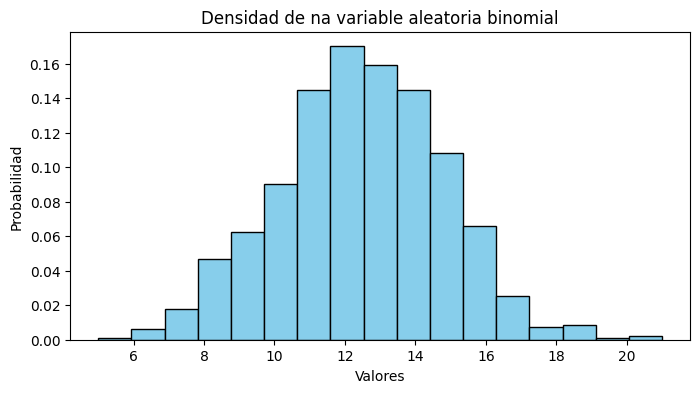

In [52]:
# Grafica de la distribucxión Binomial

# Parametros

n = 25
p = 0.5

# Generamos números aleatorios con distribución binomial
binom_numeros = sps.binom.rvs(n,p,size=1000)

#Creamos un histograma

plt.figure(figsize=(8,4))
plt.hist(
    binom_numeros,
    density=True, # normaliza para que sea función de densidad
    bins = len(np.unique(binom_numeros)),
    color = "skyblue",
    edgecolor = "k"
)
plt.xlabel("Valores")
plt.ylabel("Probabilidad")
plt.title("Densidad de na variable aleatoria binomial")
plt.show()

## Variable aleatoria Poisson

Es una distribución de probabilidad discreta que sirve para calcular la probabilidad de que ocurra un determinado número de eventos raros durante un intervalo dado (puede ser de tiempo, longitud, área, etc.

Esta variable aleatoria toma los valores sobre el conjunto $\{0,1,2,\dots\}$ y tiene un parámetro $\lambda>0$, el cual representa el número de veces que se espera que ocurra un evento durante un intervalo dado.

La función de masa de probabilidades de una variable aleatoria Poisson, $X$, está dada por:

$$
f_{X}(k)=\begin{cases}
	e^{-\lambda}\frac{\lambda^{k}}{k!} &\quad \text{si } k=0,1,2,\dots \\
	0 &\quad \text{en otro caso}
\end{cases}
$$

En efecto, es una función de masa de probabilidades debido a que

$$
\begin{align*}
\sum_{k=0}^{\infty}e^{-\lambda}\frac{\lambda^{k}}{k!} &= e^{-\lambda}\sum_{k=0}^{\infty}\frac{\lambda^{k}}{k!} \\ &= e^{-\lambda}\underbrace{\left(1+\lambda+\frac{\lambda^{2}}{2!}+\frac{\lambda^{3}}{3!}+\cdots\right)}_{\text{desarrollo de Taylor de }e^{\lambda}} \\ &= e^{-\lambda}e^{\lambda}=1.
\end{align*}
$$


Se tiene que $\mathbb{E}[X] = \lambda$ y $\text{Var}(X) = \lambda$


**Aplicaciones**

**Ejemplo:** Supongamos que el número de accidentes que ocurre en un punto tiene una distribución Poisson con parámetro $\lambda=2$.

- ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes?

  $$
  \begin{align*}
  \mathbb{P}(X>2) &= 1-\mathbb{P}(X\le 2) \\ &=1-\left[\mathbb{P}(X=0)+\mathbb{P}(X=1)+\mathbb{P}(X=2)\right] \\ &= 1-\left[\frac{e^{-2}2^{0}}{0!}+\frac{e^{-2}2^{1}}{1!}+\frac{e^{-2}2^{2}}{2!}\right] \\ &= 1-e^{-2}\left[1+2+2\right] = 1-5e^{-2} = 0.3233
  \end{align*}
  $$

- ¿Cuál es la probabilidad de que en un día ocurran más de dos accidentes, sabiendo que ocurre por lo menos uno?
  $$
  \begin{align*}
  \mathbb{P}(X>2 \mid X\ge 1) = \frac{\mathbb{P}(X>2 \cap X\ge 1)}{\mathbb{P}(X\ge 1)} = \frac{\mathbb{P}(X>2)}{\mathbb{P}(X\ge 1)} = \frac{1-\mathbb{P}(X\leq 2)}{1-\mathbb{P}(X<1)} = \frac{1-5e^{-2}}{1-e^{-2}} = \frac{0.3233}{0.8646} = 0.3739
  \end{align*}
  $$
  ya que $\mathbb{P}(X\ge 1)=1-\mathbb{P}(X<1)=1-\mathbb{P}(X=0)=1-e^{-2}$


## Aproximación de Poisson a la Binomial

La distribución de Poisson es una forma límite de la distribución binomial, es decir, es una buena aproximación cuando $n$ es suficientemente grande y $p$ suficientemente pequeña.

$\textbf{Teorema (Poisson).-}$ Sean $S_{n}\sim Bin(n,p_{n})$ bajo el regimen $$\lim_{n\to \infty}np_{n}=\lambda>0.$$
Consideremos la siguiente sucesión de números reales:

$$
a_{j}(n,p_n)=\begin{cases}\binom{n}{j}(p_n)^{j}(1-p_{n})^{n-j} & j\leq n\\
0 & j\geq n+1\end{cases}
$$

Entonces,
$$\lim_{n\to \infty}a_{j}(n,p_n)=a_{j}=e^{-\lambda}\frac{\lambda^{j}}{j!} \ \ \forall j\in \mathbb{N}.$$

El teorema anterior implica que la distribución de Poisson ofrece un modelo probabilístico adecuado para todos aquellos experimentos aleatorios en los que las repeticiones son independientes unas de otras y en los que sólo hay dos posibles resultados: éxito o fracaso, con probabilidad de éxito pequeña, y en los que el interés se centra en conocer el número de éxitos obtenidos al realizar el experimento un número suficientemente grande de veces.

Empíricamente se ha establecido, que la aproximación se puede aplicar con seguridad si $n\ge100$, $p\le 0.01$ y $np \le20$.

**Ejemplo** Supongamos que la probabilidad de que un producto producido por cierta máquina es defectuoso es de $0.1$. ¿Cuál es la probabilidad de que un lote de 10 productos contenga a lo más un producto defectuoso?

Sea $X$ el número de productos defectuosos, y sabemos que $X$ tiene una distribución binomial con parámetros $n=10$ y $p=0.1$, entonces
\begin{align*}
\mathbb{P}(X\le 1) &= \mathbb{P}(X=0)+\mathbb{P}(X=1) \\ &= \binom{10}{0}(0.1)^{0}(0.9)^{10-0}+\binom{10}{1}(0.1)^{1}(0.9)^{10-1} \\ &= 0.7361
\end{align*}

Ahora, con la distribución Poisson, tenemos que $\lambda=10(0.1)=1$, por lo que
$$\mathbb{P}(X\le 1) = \mathbb{P}(X=0)+\mathbb{P}(X=1) = \frac{e^{-1}1^{0}}{0!}+\frac{e^{-1}1^{1}}{1!} = e^{-1}+e^{-1} =0.7358$$


## Variable aleatoria Geométrica con parámetro $p\in (0,1)$.

Esta variable aleatoria cuenta el número de fracasos antes del primer éxito en ensayos bernoulli independientes con parámetro $0<p<1$, y su función de masa de probabilidades está dada por:

$$
f_{X}(k)=\begin{cases}
	p(1-p)^{k-1} &\quad \text{si } k=1,2,\dots \\
	\qquad 0 &\quad \text{en otro caso}
\end{cases}
$$

Notación. $X\sim Geo(p)$

La cual es una función de densidad ya que:

- $0\le f_{X}(k)\le 1$ para toda $x$.
- $$
  \begin{align*}
  \sum_{k\in R_{X}}f_{X}(k) &= \sum_{k=1}^{\infty}(1-p)^{k-1}p \\
  		&= p\sum_{y=0}^{\infty}(1-p)^{y} \\
  		&= p\left(\frac{1}{1-(1-p)}\right) = 1
  	\end{align*}
  $$

Si por el contrario queremos contar el número de éxitos antes del primer fracaso, tenemos que la función de está dada por:

$$
f_{X}(k)=\begin{cases}
		p^{k}(1-p) &\quad \text{si } k=0,1,2,\dots \\
		\qquad 0 &\quad \text{en otro caso}
	\end{cases}
$$

Para calcular la Esperanza y Varianza de $X$, necesitamos del siguiente lema:

**Lema 1** Sea $x$ un número real tal que $│x│<1$. Entonces,
$$\sum_{k=1}^{\infty}kx^{k-1}=\frac{1}{(1-x)^2}.$$
**Demostración.** Se tiene que
$$\frac{d}{dx}\sum_{k=1}^{\infty}x^{k}=\sum_{k=1}^{\infty}kx^{k-1}.$$
Además,
$$\sum_{k=1}^{\infty}x^{k}=\frac{x}{1-x}.$$
Por lo tanto,
$$\frac{d}{dx}\frac{x}{1-x}=\frac{1}{(1-x)^2}.$$

Como corolario,
$$\sum_{k=1}^{\infty}k(k+1)x^{k-1}=\frac{2}{(1-x)^2}.$$
En efecto,
$$\frac{d}{dx}\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{k=1}^{\infty}k(k+1)x^{k-1}.$$
Ahora,
$$\sum_{k=1}^{\infty}(k+1)x^{k}=\sum_{m=2}^{\infty}mx^{m-1}=\frac{1}{(1-x)^2}-1.$$

Usando estos resultados, la esperanza de $X$ es:
\begin{align*}
\mathbb{E}[X]&= \sum\_{x \mathop \ge 1} k p(1-p)^{k - 1}\\
&= p \frac 1 {(1 - (1-p))^2}\\
&= \frac p {p^2}\\
&=\frac{1}{p}
\end{align*}

Calculamos,
\begin{align*}
\mathbb{E}[X^2]&= \sum*{k=1}^{\infty} x^{2}p(1-p)^{k-1}\\
&=\sum*{k=1}^{\infty}k(k+1)(1-p)^{k-1}p-\sum\_{k=1}^{\infty}p(1-p)^{k-1}
\end{align*}

Por el Lema 1,
$$\mathbb{E}[X^2]=p\frac{2}{p^3}-\frac{1}{p}=\frac{2}{p^2}-\frac{1}{p}.$$

Por lo tanto,
$$\text{Var}(X)=\frac{2}{p^2}-\frac{1}{p}-\frac{1}{p^2}=\frac{1-p}{p^2}.$$


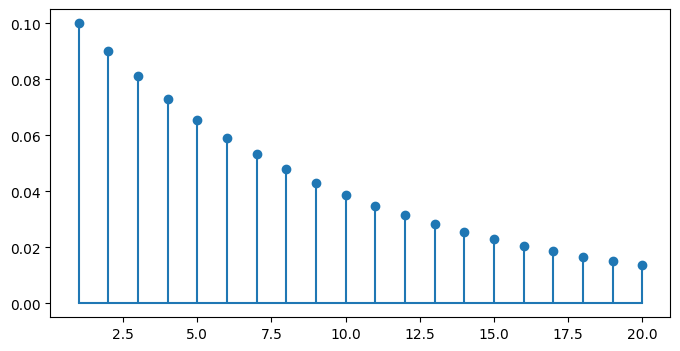

In [53]:
# Ahora vamos a gráficar la distribución geométrica

from scipy.stats import geom

# El parametro es
p = 0.1

# Valores posibles
x = np.arange(1,21) # De 1 a 20 ensayos

pmf_geo = geom.pmf(x,p)

plt.figure(figsize=(8,4))
plt.stem(x,pmf_geo,basefmt="")
plt.show()

## Variable aleatoria Binomial Negativa con parámetros $r\geq 1$ y $p\in (0,1)$.

Supongamos que se realizan ensayos independientes, cada uno con probabilidad $0<p<1$ de ser un éxito, hasta obtener un total de $r$ éxitos acumulados. Sea $X$ el número de ensayos que se requieren, entonces su función de masa de probabilidades está dada por:

$$
f_{X}(k)=\begin{cases}
	\binom{k-1}{r-1}p^{r}(1-p)^{k-r} &\quad \text{si } k=r,r+1,\dots \\
	\qquad 0 &\quad \text{en otro caso}
\end{cases}
$$

Notación. $X\sim \text{BN}(r,p)$.

Se tiene que
$$\mathbb{E}[X]=\frac{r}{p}$$
y
$$\text{Var}[X]=\frac{r(1-p)}{p^2}.$$


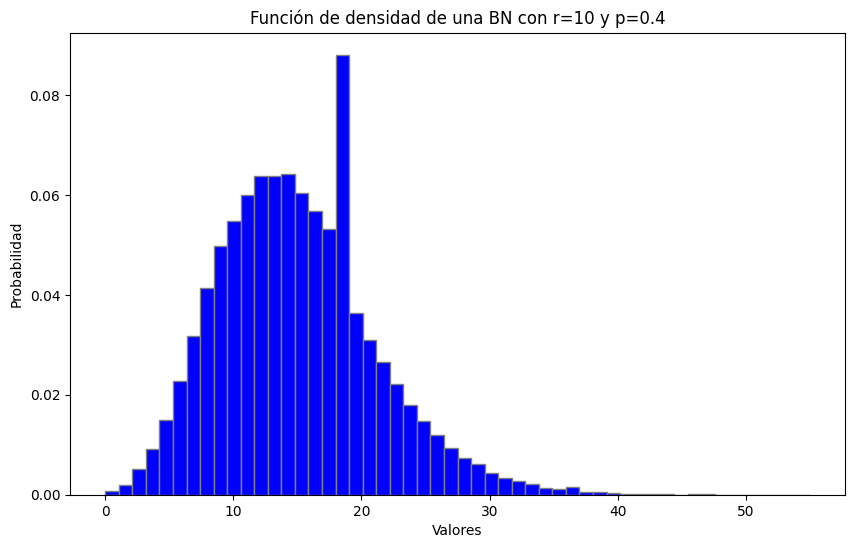

In [54]:
r = 10
p = 0.4 # probabilidad de éxito
s= 100000 # número de muestras

np.random.seed(3) #fijar una semilla
#Vamos a generar numeros aleatorios que siguen una distribución geométrica
nbinom_numeros = sps.nbinom.rvs(r,p,size=s)

#Creamos un histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_numeros,
    density=True, # Normaliza el area para que sea 1
    bins=len(np.unique(nbinom_numeros)), # número de barras del histograma
    color = "blue",
    edgecolor="grey"
)

plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Función de densidad de una BN con r=10 y p=0.4')
plt.show() #mostrar el gráfica

In [55]:
import numpy as np # Para cálculos numéricos
import matplotlib.pyplot as plt # Para crear gráficas
import scipy.stats as sps # Para distribuciones discretas y continuas, pruebas estadísticas
from scipy.stats import geom, nbinom # Para distribuciones geométrica y binomial negativa

$\color{red}{\text{Ejercicio 2.}}$ Un examen de Estadística consta de 20 preguntas tipo test y se conoce de experiencias
anteriores que un alumno tiene probabilidad 0.7 de contestar bien cada pregunta. Obtener:

a) La probabilidad de que la primera pregunta que contesta bien sea la cuarta.


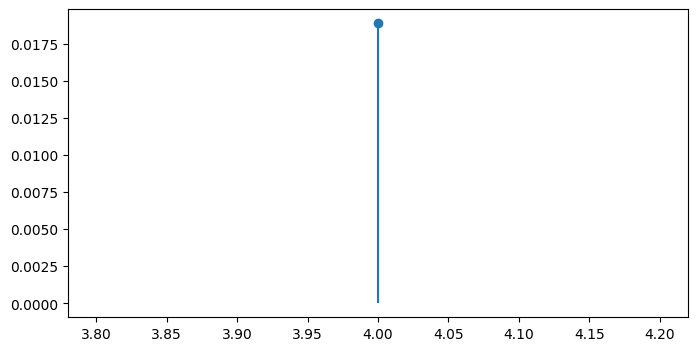

In [56]:
ej2a = geom.pmf(4,0.7)
plt.figure(figsize=(8,4))
plt.stem(4,ej2a,basefmt="")
plt.show()

In [57]:
print('a) La probabilidad de que el primer éxito ocurra en el cuarto intento es:', ej2a)

a) La probabilidad de que el primer éxito ocurra en el cuarto intento es: 0.018900000000000007


b) Sabiendo que para aprobar el examen es necesario contestar bien a 10 preguntas, ¿cuál es la probabilidad de que apruebe al contestar la pregunta duodécima?


In [58]:
ej2b = nbinom.pmf(2, 10, 0.7)

print("b) La probabilidad de que el décimo éxito ocurra en el duodécimo intento es:", ej2b)

b) La probabilidad de que el décimo éxito ocurra en el duodécimo intento es: 0.13982524825499987


TypeError: 'int' object is not callable

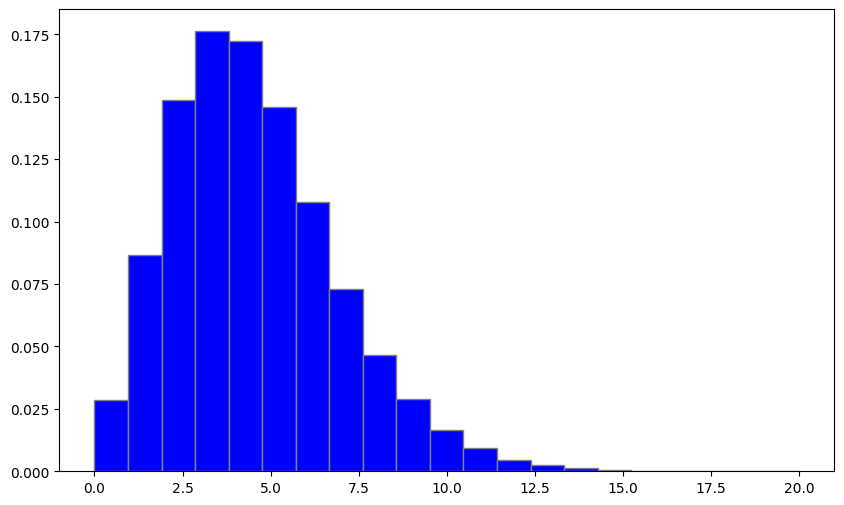

In [59]:
r = 10 # número de éxitos
p = 0.7 # probabilidad de éxito
s= 100000 # número de muestras

np.random.seed(3) #fijar una semilla
#Vamos a generar numeros aleatorios que siguen una distribución geométrica
nbinom_numeros = sps.nbinom.rvs(r,p,size=s)

#Creamos un histograma
plt.figure(figsize=(10,6))
plt.hist(
    nbinom_numeros,
    density=True, # Normaliza el area para que sea 1
    bins=len(np.unique(nbinom_numeros)), # número de barras del histograma
    color = "blue",
    edgecolor="grey"
)
plt.xticks(np.arange(0, max(nbinom_numeros)+1, 1)) # Establecer los ticks del eje x
plt.xlabel('Valores')
plt.ylabel('Probabilidad')
plt.title('Función de densidad de una BN con r=10 y p=0.7')
plt.show() #mostrar el gráfica

#Continuas

## Variable aleatoria exponencial con parámetro $\lambda >0$.

La distribución exponencial es una de las distribuciones continuas más utilizadas. A menudo se utiliza para modelar el tiempo transcurrido entre eventos.

Algunos ejemplos en los que podría utilizarse la distribución exponencial son:

- El tiempo transcurrido en un call center hasta recibir la primer llamada del día.
- El tiempo entre terremotos de una determinada magnitud.
- Supongamos una máquina que produce hilo de alambre, la cantidad de metros de alambre hasta encontrar una falla en el alambre se podría modelar como una exponencial.

Se dice que la variable aleatoria $X$ tiene distribución exponecial de parámetro $\lambda>0$, si su función de densidad está dada por:

$$
f_{X}(x)=\begin{cases}
\lambda e^{-\lambda x} & x>0\\
0 & \text{en otro caso}
\end{cases}
$$

Notación. $X\sim \exp(\lambda).$

$\textbf{Propiedad de pérdida de memoria:}$
$$\mathbb{P}(X>t+s \mid X>t)=\mathbb{P}(X>s)=e^{-\lambda s}.$$

Ejercicio: Demostrar la propiedad de pérdida de memoria para $X\sim \exp(\lambda)$.

La esperanza y varianza de de una distribución exponencial de la forma $$f_{X}(x)=\begin{cases}
\frac{1}{\lambda} e^{-\frac{x}{\lambda}} & x>0\\
0 & \text{en otro caso}
\end{cases}$$:
$$\mathbb{E}[X]= \int_{0}^{\infty}xf_{x}(x)dx = \int_{0}^{\infty}x\frac{1}{\lambda}e^{-\frac{x}{\lambda}}dx = \lambda$$
y
\begin{align*}
\text{Var}(X) &= \mathbb{E}[X^{2}]-(\mathbb{E}[X])^{2} = \int*{0}^{\infty}x^{2}f*{x}(x)dx-\lambda^{2} \\ &= \int\_{0}^{\infty}x^{2}\frac{1}{\lambda}e^{-\frac{x}{\lambda}}dx - \lambda^{2} = \lambda^{2}
\end{align*}

Se tiene que la función de distribución de la v.a. exponencial:

$$ F*{X}(x) = \mathbb{P}(X\le x) = \int*{0}^{x}\lambda e^{-\lambda u} du = 1- e^{-\lambda x}$$


**Ejemplo**

Consideremos la variable aleatoria $X$ como el tiempo (en minutos) entre la llegada de dos personas a la fila de una sucuarsal bancaria.

Adicionalmente, el banco ha determinado que solo el $10\%$ de las veces, el tiempo que transcurre entre la llegada de una persona y otra es mayor a dos minutos.

Esto permite calcular el valor de $\lambda$, ya que
$$\mathbb{P}(X>2)=0.1$$
entonces
$$1-\mathbb{P}(X\le 2) = 1-F_{X}(2) = 0.1$$

Notemos que si $X\sim Exp\left( \lambda \right)$, entonces
$$F_{X}(x) = 1-e^{-\frac{x}{\lambda}} $$

Por lo que $F_{X}(2)= 1-e^{\frac{-2}{\lambda}} =0.9$, entonces
$e^{\frac{-2}{\lambda}}=0.1$. Por lo que
$$\frac{-2}{\lambda}=\ln(0.1) \Rightarrow \lambda=0.87$$
Por lo tanto $X\sim\exp(0.87)$.

Ahora queremos calcular la probabilidad de que entre la llegada de una persona y otra transcurra por lo menos un minuto, lo cual puede calcularse de dos formas:

\begin{align*}
\mathbb{P}(X>1) &= \int*{1}^{\infty}f*{X}(x)dx = \int\_{1}^{\infty}\frac{1}{0.87}e^{\frac{-x}{0.87}}dx = 0.32
\end{align*}

\begin{align*}
\mathbb{P}(X>1) &= 1-\mathbb{P}(X\le 1) = 1-\left[1-e^{\frac{-1}{0.87}}\right] = e^{\frac{-1}{0.87}}
\end{align*}


$\color{red}{\text{Ejercicio 2.}}$ Calcular las probabilidades con Scipy


Una propiedad interesante de la distribución exponencial es que puede verse como un análogo continuo de la distribución geométrica. Para ver esto, recuerde el experimento aleatorio detrás de la distribución geométrica: lanza una moneda (repite un experimento de Bernoulli) hasta que observa las primeras caras (éxito).

$\mathbf{Teorema.-}$ Sea $\varepsilon>0$ y $Y_{\epsilon}\sim Geo(p_{\varepsilon})$. Supongamos que nos encontramos en el regimen:
$$\lim_{\varepsilon\to 0}p_{\varepsilon}=0 \qquad \text{y} \qquad \varepsilon^{-1}p_{\varepsilon}\sim \lambda>0$$
Sea $X_{\varepsilon}:=\varepsilon Y_{\varepsilon}$. Entonces,
$$\lim_{\varepsilon\to 0}F_{X_{\varepsilon}}(x)=F_{X}(x),$$
en donde $X\sim \exp(\lambda)$. Este también es un resultado de convergencia en ley.


# Variable aleatoria normal con parámetros media $\mu$ y varianza $\sigma^{2}$.

La distribución normal es una de las más importantes y de mayor uso tanto en la teoría de la probabilidad, como en la teoría estadística.

También llamada distribución gaussiana, en honor a Gauss, a quien se considera el padre de ésta distribución.

La importancia de la distribución normal, radica en el famoso Teorema central del límite. Fue descubierta por De Moivre en 1733 como un límite de la distribución binomial.

La importancia de esta distribución radica en que permite modelar numerosos fenómenos naturales, sociales y psicológicos, por ejemplo:

- Estatura
- Efectos de un fármaco
- Consumo de cierto producto por un grupo de individuos
- Coeficiente intelectual
- Nivel de ruido en telecomunicaciones
- Errores cometidos al medir ciertas magnitudes

Además, esta distribución juega un papel de suma importancia en la inferencia estadística.

Se dice que la variable aleatoria $X$ tiene distribución normal de parámetros $\mu$ y $\sigma^{2}$, donde $\mu,\sigma\in\mathbb{R}$ y $\sigma>0$, si su función de densidad está dada por:

$$
f_{X}(x)=\begin{cases}
	\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-\mu)^{2}}{2\sigma^{2}}} &\quad \text{si }  x \in\mathbb{R} \\
	\qquad 0 &\quad \text{e.o.c}
\end{cases}
$$

**Notación.** $X\sim N(\mu,\sigma^{2})$

Tal curva (**la campana de Gauss-Bell**) es una función que depende de los parámetros $\mu$ y $\sigma^{2}$.

**Observación:** El parámetro $\mu$ se llama _media_ y el parámetro $\sigma^{2}$ se llama _varianza_.

La función de densidad definida anteriormente es efecto función de densidad, ya que
$$\int_{\mathbb{R}}f_{X}(x)dx = \int_{\mathbb{R}}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(x-m)^{2}}{2\sigma^{2}}}  = 1 $$

Variable aleatoria normal con parámetros 0 y 1 .
La ley de $Z\sim N(0,1)$ está dada por la función de densidad

$$
f_{Z}(z) = \frac{1}{\sqrt{2\pi}}e^{-\frac{z^2}{2}},
$$

para $z\in \mathbb{R}$.

Sabemos que:

- La varianza es usada como una medida para comparar la dispersión en dos o más conjuntos de observaciones.
- Una desviación estándar pequeña indica que los valores de la variable aleatoria se encuentran cercanos a la media.
- Una desviación estándar grande indica que los valores de la variable aleatoria se dispersan mucho con respecto a la media.

La función de distribución de una variable aleatoria $X\sim N(\mu,\sigma^{2})$ está dada por:
$$F_{X}(x) = \int_{-\infty}^{x}\frac{1}{\sqrt{2\pi\sigma^{2}}}e^{-\frac{(y-\mu)^{2}}{2\sigma^{2}}}dy$$

Esta nos proporciona la probabilidad de que $X$ tome calores menores o iguales a un valor específico $x$, y corresponde al área bajo la curva en el intervalo $(-\infty,x]$:

No es sencillo calcular $F_{X}(x)$, pero cualquier v.a. gaussiana puede transformarse a una v.a. estandarizada. Existen tablas para esta v.a., lo cual hace los cálculos más fáciles.

**Proposición** Sea $X\sim N(\mu,\sigma^{2})$, entonces
$$Z=\frac{X-\mu}{\sigma}$$
tiene una distribución gaussiana con media $0$ y varianza $1$, es decir, $Z\sim N(0,1)$.

**Demostración** Primero vamos a calcular la función de distribución de $Z$:
$$F_{Z}(z):=\mathbb{P}(Z\le z) = \mathbb{P}\left(\frac{X-\mu}{\sigma}\le z\right) = \mathbb{P}(X\le \sigma z + \mu) := F_{X}(\sigma z + \mu)$$
Entonces, la función de densidad de $Z$ esta dada por:
$$f_{Z}(z) = \frac{dF_{Z}(z)}{dz} = \frac{dF_{X}(\sigma z + \mu)}{dz} = \sigma f_{X}(\mu+\sigma z) = \frac{e^{-z^{2}/2}}{\sqrt{2\pi}}$$

Podemos calcular cualquier probabilidad de la forma
$$\mathbb{P}(a<X<b)$$
de la siguiente manera: para $z\ge 0$, definimos
$$\Phi(z) = \frac{1}{\sqrt{2\pi}}\int_{0}^{z}e^{-x^{2}/2}dx.$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm #importar la distribución normal
fig, ax = plt.subplots()
x= np.arange(-6,6,0.001) #generar valores de x
ax.set_title('Distribución normal estándar N(0,$1^2$)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.plot(x, norm.pdf(x)) # se grafica la función de densidad
ax.set_ylim(0,0.45)
plt.show()

Propiedades de la función de densidad de probabilidades de una distribución normal estándar:

1. Es positiva: $f(x)\geq 0$ para todo $x$ real.
2. Es continua y derivable en todas partes.
3. Es simétrica alrededor de $\mu$.
4. Conforme $x$ toma valores muy grandes de manera positiva y negativa, la función decrece hacia cero muy rápidamente.
5. Tiene un máximo global.
6. El área total bajo la curva es igual a $1$.


Veamos el comportamiento de la función conforme se cambia la varianza.


In [ ]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100) # valores de x entre -10 y 10 (funciona como el dominio)
stdvs = [0.5, 0.7, 1.0, 2.0, 3.0, 4.0]
for s in stdvs:
    ax.plot(x, norm.pdf(x,scale=s), label='stdv=%.1f' % s)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Distribución normal con media 0')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,1)
ax.grid(True)

Veamos el comportamiento de la función conforme se cambia la media.


In [ ]:
from scipy.stats import norm
fig, ax = plt.subplots()
x = np.linspace(-10,10,100)
means = [-1.0,-2.0, -1.0, 0.0, 1.0, 2.0, 5.0]
for mean in means:
    ax.plot(x, norm.pdf(x,loc=mean), label='mean=%.1f' % mean)

ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.set_title('Distribución normal')
ax.legend(loc='best', frameon=True)
ax.set_ylim(0,0.45)
ax.grid(True)

### Función de distribución de una normal $N(\mu,\sigma^2)$.

Gracias a las propiedades anteriores, es posible calcular áreas delimitadas de la función $f$. Si $a$ y $b$ son reales cualesquiera, denotaremos por
$$P(a\leq X\leq b),$$
la probabilidad de que $X$ esté en el intervalo $[a,b]$, al área bajo la curva de $f(x)$ sobre el intervalo $[a,b]$.

También, $P(X\leq x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(-\infty,x)$ y $P(X>x)$ denotara al área bajo la curva de la función $f(x)$ sobre el intervalo $(x, \infty)$.


A la probabilidad $\text{cdf}(x):=P(X\leq x)$ se llama la distribución acumulativa (hasta el valor $x$) de $f(x)$.

Con la notación anterior,
$$P(a\leq X\leq b)=\text{cdf}(b)-\text{cdf}(a)$$
y
$$\text{sf}(a):=P(X>a)=1-\text{cdf}(a).$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, ax=plt.subplots()

# valores del eje horizontal
x = np.arange(-4,4,0.001)

ax.plot(x, norm.pdf(x))

ax.set_title("Distribución normal acumulada")
ax.set_xlabel("x")
ax.set_ylabel("pdf(x)")
ax.grid(True)

# Rellenamos el área bajo la curva
px = np.arange(-4,1,0.001) # desde -4 hasta 1
ax.set_ylim(0,0.5) # limites del eje vertical
ax.fill_between(px,norm.pdf(px),alpha=0.25, color='b') # rellenar
ax.text(-1,0.1,"cdf(x)",fontsize=15)
plt.show()

### Cálculo de probabilidades de una distribución normal


Calculemos $\text{cdf}(2)=\mathbb{P}(X\le2)$ cuando $X\sim N(3,2^2)$.


$$Z = \frac{X-\mu}{\sqrt{\sigma^2}} \sim N(0,1)$$


In [ ]:
prob = norm.cdf(x=2, loc=3, scale=2)
print(prob)

In [ ]:
fig, ax=plt.subplots()
# valores del eje horizontal
x = np.arange(-5,10,0.001)
ax.plot(x, norm.pdf(x,loc=3,scale=2))

ax.set_title("Distribución normal acumulada de N(3,$2^2$)")
ax.set_xlabel("x")
ax.set_ylabel("pdf(x)")
ax.grid(True)

# Rellenamos el área bajo la curva
px = np.arange(-5,2,0.001) # desde -5 hasta 2
ax.set_ylim(0,0.5) # limites del eje vertical
ax.fill_between(px,norm.pdf(px,loc=3,scale=2),alpha=0.25, color='b') # rellenar
ax.text(0,0.025,round(norm.cdf(x=2, loc=3, scale=2),3),fontsize=15)
plt.show()

Calculemos $\mathbb{P}(0.5<𝑋<2)$ cuando $X\sim N(1,2)$.


In [ ]:
s=np.sqrt(2)
norm(1, s).cdf(2) - norm(1,s).cdf(0.5)

In [ ]:
fig, ax = plt.subplots()
x= np.arange(-6,8,0.001)
ax.plot(x, norm.pdf(x,loc=1,scale=2))
ax.set_title("N(1,$2^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(0.5,2,0.01)
ax.set_ylim(0,0.25)
ax.fill_between(px,norm.pdf(px,loc=1,scale=2),alpha=0.5, color='g')
pro=norm(1, 2).cdf(2) - norm(1,2).cdf(0.5)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

**Ejemplo importante** Si $Z\sim N(0,1)$, encuentra $\mathbb{P}(-1.93 < Z < 1.93)$. La probabilidad buscada es:


In [ ]:
norm(0,1).cdf(1.93)-norm(0,1).cdf(-1.93)

In [ ]:
fig, ax = plt.subplots()
# for distribution curve
x= np.arange(-3,3,0.001)
ax.plot(x, norm.pdf(x,loc=0,scale=1))
ax.set_title("N(0,$1^2$)")
ax.set_xlabel('x')
ax.set_ylabel('pdf(x)')
ax.grid(True)
px=np.arange(-1.93,1.93,0.01)
ax.set_ylim(0,0.45)
ax.fill_between(px,norm.pdf(px,loc=0,scale=1),alpha=0.5, color='g')
pro=norm(0, 1).cdf(1.93) - norm(0,1).cdf(-1.93)
ax.text(0.2,0.02,round(pro,2), fontsize=20)
plt.show()

### Cálculo de probabilidades:

$\mathbb{P}(0<Z<b)$: Queremos calcular $\mathbb{P}(0<Z<0.43)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(0<Z<0.43) = 0.1664$

$\mathbb{P}(-b<Z<b)$: Queremos calcular $\mathbb{P}(-0.16<Z<0.16)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(-0.16<Z<0.16) = \mathbb{P}(-0.16<Z<0)+\mathbb{P} (0<Z<0.16) = \mathbb{P}(0<Z<0.16)+\mathbb{P}(0<Z<0.16) = 2\mathbb{P}(0<Z<0.16) = 2(0.0636) = 0.1272$

$\mathbb{P}(Z<-b)$: Queremos calcular $\mathbb{P}(Z<-1.94)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(Z<-1.94) = \mathbb{P}(Z<0)+\mathbb{P}(-1.94<Z<0) = \mathbb{P}(Z<0) + \mathbb{P}(0<Z<1.94) = 0.5 - 0.4738 = 0.0262$

$\mathbb{P}(Z>-b)$: Queremos calcular $(Z>-0.07)$, lo cuál puede realizarse de la siguiente manera:

- Tablas de área a la derecha: $\mathbb{P}(Z>-0.07) = \mathbb{P}(-0.07<Z<0) + \mathbb{P}(Z>0) = \mathbb{P}(0<Z<0.07) + \mathbb{P}(Z>0) = 0.0279 + 0.5 = 0.5279$


La función generadora de momentos de una variable aleatoria $X$ se define como:

$$M_x(t)= \sum_ee^{tx}P(X=x)$$ si X es discreta

o en su caso

$$M_x(t)= \int_{-∞}^{∞}e^{tx}f(x)dx$$

La función característica de una variable aleatoria $X$ se define como:

$$\phi_x(t)= \sum_ee^{itx}P(X=x)$$ si X es discreta

o en su caso

$$\phi_x(t)= \int_{-∞}^{∞}e^{itx}f(x)dx$$

| Función                | Expresión    | Usa              |
| ---------------------- | ------------ | ---------------- |
| Generadora de momentos | :$(E(e^{tX}))$  | Momentos         |
| Característica         | $(E(e^{itX}))$ | Análisis teórico |


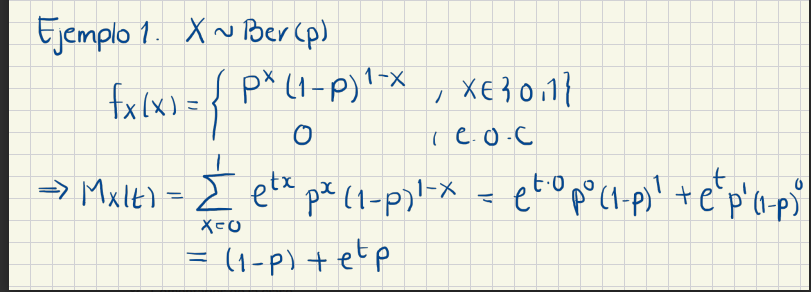

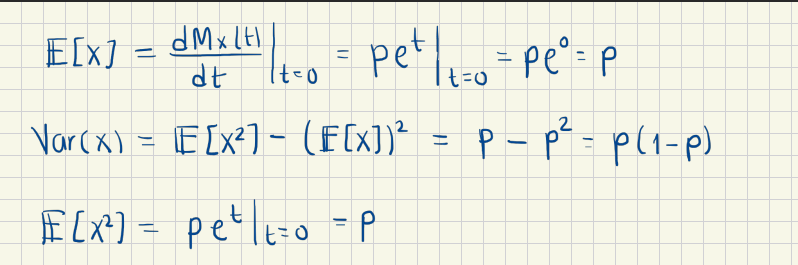

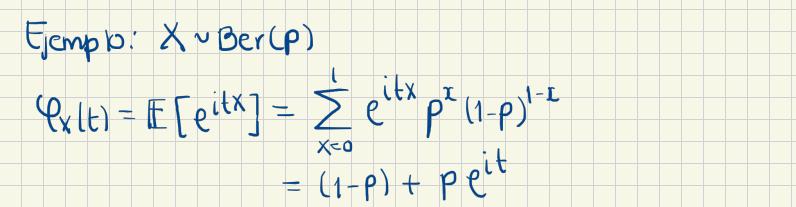

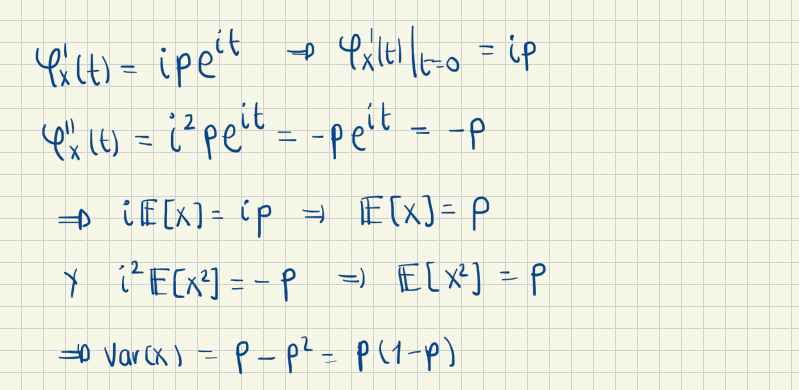

# LEY DE LOS GRANDES NÚMEROS Y TEOREMA DEL LÍMITE CENTRAL

La **Ley de los Grandes Números** establece que, a medida que aumentamos el número de repeticiones de un experimento aleatorio, el valor promedio de los resultados observados se aproxima al valor esperado. Es decir, mientras más veces se repite un experimento, más se acerca la media de los resultados al valor teórico esperado.

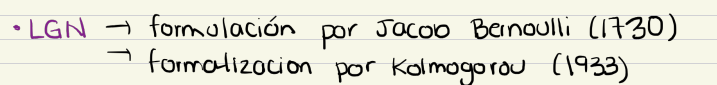

In [ ]:
import numpy as np
import pandas as pd #Manejo y manipulacion de datos
import matplotlib.pyplot as plt
import seaborn as sns #Visualizacion de datos

## Simulación de la LGN

Simualaremos los lanzamientos de un dado y calcularemos la media

$$ \Omega = \{ 1,2,3,4,5,6, \}$$

La media teórica : $$\mathbb{E}[X] = 3.5$$

In [ ]:
np.random.seed(42) # numeros pseudoaletorios sean reproducibles
lanzamientos = np.random.randint(1,7,10000)

In [ ]:
media_acum = np.cumsum(lanzamientos) / np.arange(1,10001)
df = pd.DataFrame( {
    'Lanzamiento': np.arange(1,10001),
    'Media Acumulada': media_acum } )

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(df['Lanzamiento'], df['Media Acumulada'], label='media muestral')
plt.axhline(3.5, color= 'red', linestyle='--', label='media teórica (3.5)')
plt.xlabel('Número de lanzamientos')
plt.ylabel('Media')
plt.title('LGN en lanzamientos de un dado')
plt.legend()
plt.show()

## Problema de la Ajuga de Bufon

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del problema
L = 1.0  # Longitud de la aguja
d = 1.0  # Distancia entre las líneas paralelas
num_trials = 100000  # Número total de lanzamientos
step = 1000  # Número de lanzamientos por paso para la estimación de pi

# Listas para almacenar los valores de pi estimados y los lanzamientos
pi_estimates = []
trial_steps = []

# Contador para cuántas agujas cruzan una línea
crossed_lines = 0

# Simulación de lanzamientos de la aguja y estimación de pi en pasos
for trial in range(1, num_trials + 1):
    # Posición del centro de la aguja
    center_position = np.random.uniform(0, d / 2)

    # Ángulo aleatorio entre 0 y pi (ángulo en radianes)
    angle = np.random.uniform(0, np.pi)

    # Distancia desde el centro de la aguja hasta la línea más cercana
    distance_to_nearest_line = L / 2 * np.sin(angle)

    # Verificamos si la aguja cruza una línea
    if center_position <= distance_to_nearest_line:
        crossed_lines += 1

    # Estimación de pi en pasos
    if trial % step == 0 and crossed_lines > 0:
        pi_estimate = (2 * L * trial) / (crossed_lines * d)
        pi_estimates.append(pi_estimate)
        trial_steps.append(trial)

print(f"Estimación de pi: {pi_estimate}")

# Plot de la estimación de pi a lo largo de los lanzamientos
plt.figure(figsize=(10, 6))
plt.plot(trial_steps, pi_estimates, label="Estimación de π", color="blue")
plt.axhline(y=np.pi, color="red", linestyle="--", label="Valor real de π")
plt.xlabel('Número de lanzamientos')
plt.ylabel('Estimación de π')
plt.title('Convergencia de la estimación de π con el problema de la aguja de Buffon')
plt.legend()
plt.grid(True)
plt.show()

# TEOREMA CENTRAL DEL LÍMITE

El teorema del límite central (TLC) establece que, al tomar muestras aleatorias suficientemente grandes ($n \geq 30$) de cualquier población, la distribución de las medias muestrales seguirá una distribución aproximadamente normal, independientemente de la forma de la distribución original de la población.

## Ejemplo

/tmp/ipykernel_771/4110262981.py:15: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_muestra_medias)


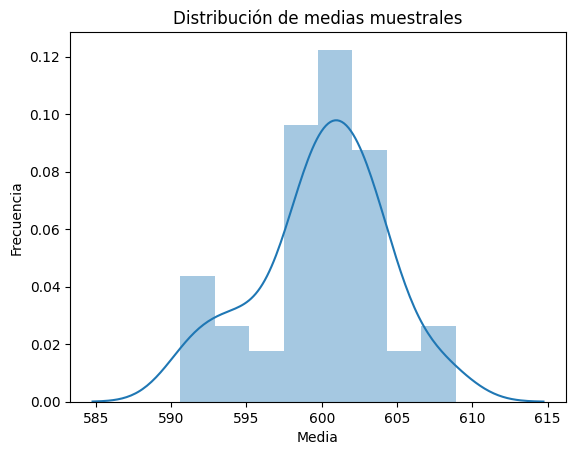

In [61]:

# Crear el DataFrame con 50 muestras, cada una con 10 observaciones de una binomial(n=1000, p=0.6)
df = pd.DataFrame()

for i in range(1,51):
  muestra = np.random.binomial(1000,0.6,10)  # Muestra aleatoria de binomiales de 10 éxitos, se realiza 1000 veces el experimento
  col = f"muestra {i}"
  df[col] = muestra

df.head(5)  # Mostrar las primeras 5 filas

# Calcular el promedio de cada muestra
df_muestra_medias = pd.DataFrame(df.mean(), columns=["Media de la muestra"])

# Visualizar la distribución de las medias
sns.distplot(df_muestra_medias)
#sns.histplot(df_muestra_medias["Media de la muestra"], kde=True)
plt.title("Distribución de medias muestrales")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.show()